A test to see which number is more suitable for set_num_threads

In [ ]:
# import torch
# import time
#
# def benchmark_threads(num_threads, matrix_size=4000, iterations=20):
#     # Set the number of threads for this test run
#     torch.set_num_threads(num_threads)
#
#     # Create two massive random matrices to simulate deep learning workloads
#     A = torch.randn(matrix_size, matrix_size)
#     B = torch.randn(matrix_size, matrix_size)
#
#     # Warmup round (gets the CPU caches loaded and ready)
#     _ = torch.matmul(A, B)
#
#     # Start the actual timer
#     start_time = time.time()
#
#     # Run the heavy math multiple times
#     for _ in range(iterations):
#         _ = torch.matmul(A, B)
#
#     end_time = time.time()
#
#     print(f"Total time with {num_threads} threads: {end_time - start_time:.4f} seconds")
#
# print("--- PyTorch CPU Thread Benchmark ---")
# # Test with 4 threads
# benchmark_threads(4)
#
# # Test with 8 threads
# benchmark_threads(8)

8 threads is faster than 4 threads, so we will use 8 threads for the rest of the code

Cell 1: Imports and Device Setup

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import time
from ofdm.ccdf import plot_ccdf, plot_ccdf_compare
from ofdm.metrics import calculate_papr, calculate_cm
import matplotlib.pyplot as plt

In [22]:
# 1024 features based on N=256 and oversampling L=4
input_features = 256 * 4

# Modulation scheme
mod = "16qam"
# mod = "qpsk"
print(f"Using {mod.upper()} modulation technique)")

# Hyperparameters
epochs = 100
lr = 0.001 # originally 0.001
lr_str = "dot" + str(lr).split(".")[1]
print(f"Hyperparameters: epochs = {epochs}, learning rate = {lr} ({lr_str} used in naming files), batch size = None (for now)")

# Data splitting
train_size = 80
test_size = (100 - train_size) or 1
train_test_str = f"{train_size}_{test_size}"
if train_size < 100:
    one_batch = None
elif train_size == 100:
    one_batch = "00"
print(f"dataset is split into {train_size} training files and {test_size} batches ({train_test_str} used in naming files, while {one_batch} is the index of used batch if testing on 1 batch)")
if train_size == 100:
    print("This 1 batch is of index 00, and was already used in training")

batch_suffix = f" (Batch #{one_batch})" if one_batch else ""
params = f"{mod.upper()} lr = {lr} ({train_size} Training/{test_size if not one_batch else 1} Testing){batch_suffix}"
print(params)

Using 16QAM modulation technique)
Hyperparameters: epochs = 100, learning rate = 0.001 (dot001 used in naming files), batch size = None (for now)
dataset is split into 100 training files and 1 batches (100_1 used in naming files, while 00 is the index of used batch if testing on 1 batch)
This 1 batch is of index 00, and was already used in training
16QAM lr = 0.001 (100 Training/1 Testing) (Batch #00)


In [3]:
# Explicitly tell PyTorch to utilize your 8 CPU cores for matrix math
# Check for GPU availability to drastically speed up training
# ! cuda is available only on nvidia gpu
torch.set_num_threads(8)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch using {torch.get_num_threads()} threads on {device}")

PyTorch using 8 threads on cpu


Cell 1.5: Changing the data format from .npz to .pt for faster loading (one-time setup)

In [ ]:
# def normalize_and_save():
#     input_dir = "./data_npz/"
#     output_dir = "./data_pt/"
#     os.makedirs(output_dir, exist_ok=True)
#
#     print("Converting .npz to normalized .pt files...")
#     for i in range(100):
#         print(f"Processing file {i + 1}/100: {mod}_tx_rx_32_part_{i:02d}.npz")
#         # 1. Load the slow .npz file
#         try:
#             data = np.load(os.path.join(input_dir, f"{mod}_tx_rx_32_part_{i:02d}.npz"))
#         except FileNotFoundError:
#             break
#         X_raw = data['tx']
#         Y_raw = data['rx']
#
#         # 2. Extract Real and Imaginary
#         for part_idx, part_name in enumerate(['real', 'imag']):
#             X_batch = torch.tensor(X_raw[part_idx, :, :], dtype=torch.float32)
#             Y_batch = torch.tensor(Y_raw[part_idx, :, :], dtype=torch.float32)
#
#             # 3. Normalize once and for all
#             X_min, X_max = X_batch.min(), X_batch.max()
#             Y_min, Y_max = Y_batch.min(), Y_batch.max()
#
#             X_norm = 2.0 * ((X_batch - X_min) / (X_max - X_min)) - 1.0 if X_max != X_min else X_batch
#             Y_norm = 2.0 * ((Y_batch - Y_min) / (Y_max - Y_min)) - 1.0 if Y_max != Y_min else Y_batch
#
#             # 4. Save as a hyper-fast PyTorch file
#             torch.save((X_norm, Y_norm), os.path.join(output_dir, f"{mod}_tx_rx_32_part_{i:02d}_{part_name}.pt"))
#
#     print("Done! You never have to do this math again.")
#
# normalize_and_save()

Cell 2: Custom Activation Function

In [4]:
class TriangularActivation(nn.Module):
    """
    Implements the triangular activation function used in the paper's hidden layers.
    Mathematically equivalent to MATLAB's 'tribas': f(x) = max(1 - |x|, 0)
    """
    def forward(self, x):
        return torch.clamp(1.0 - torch.abs(x), min=0.0)

Cell 3: Highly Optimized Dataset Class

This is fast as it works with .pt directly without conversion

In [5]:
class FastOFDMDataset(Dataset):
    def __init__(self, pt_folder_path, part):
        self.folder_path = pt_folder_path
        self.part = part

    def __len__(self):
        return 100 # Assuming exactly 100 pre-computed .pt files, regardless of train/test split

    def __getitem__(self, idx):
        # Instantly loads the pre-normalized tensors directly into memory!
        file_path = os.path.join(self.folder_path, f"{mod}_tx_rx_32_part_{idx:02d}_{self.part}.pt")
        X_norm, Y_norm = torch.load(file_path, weights_only=True)
        return X_norm, Y_norm

Cell 4: Neural Network Architecture

In [6]:
class NNICFMapper(nn.Module):
    def __init__(self, input_size):
        super(NNICFMapper, self).__init__()
        # First hidden layer: 2 neurons
        self.hidden1 = nn.Linear(input_size, 2)
        # Second hidden layer: 1 neuron
        self.hidden2 = nn.Linear(2, 1)
        # Output layer: Maps back to the original subcarrier points
        self.output = nn.Linear(1, input_size)
        # Custom triangular activation
        self.activation = TriangularActivation()

    def forward(self, x):
        x = self.activation(self.hidden1(x))
        x = self.activation(self.hidden2(x))
        x = self.output(x) # Standard linear output
        return x

Cell 5: Initialization and DataLoaders

In [7]:
# --- Configuration ---
# The path where 100 .pt files are saved!
file_directory = "./data_pt/"

# Initialize DataLoaders with asynchronous loading (num_workers) and rapid memory transfer
train_dataset_real = FastOFDMDataset(file_directory, part='real')
if train_size < 100:
    # ! note that the output of the Subset is saved in the original variable, may be important later
    train_dataset_real = Subset(train_dataset_real, range(train_size))  # Use the first train_size files for training
train_loader_real = DataLoader(
    train_dataset_real,
    batch_size=None, # batch_size is None because the dataset returns a full batch of 10,000
    shuffle=True,
    # ! does not work locally on windows when changed to 2-4 for some reason
    num_workers=0,   # Adjust between 2-4 based on your CPU cores
    pin_memory=torch.cuda.is_available()
)

train_dataset_imag = FastOFDMDataset(file_directory, part='imag')
if train_size < 100:
    train_dataset_imag = Subset(train_dataset_imag, range(train_size))  # Use the first train_size files for training
train_loader_imag = DataLoader(
    train_dataset_imag,
    batch_size=None,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# Initialize models and send them to the GPU/device
Mod_Re_NN = NNICFMapper(input_features).to(device)
Mod_Im_NN = NNICFMapper(input_features).to(device)

# Standard Mean Squared Error loss and Adam optimizer
criterion = nn.MSELoss()
optimizer_real = optim.Adam(Mod_Re_NN.parameters(), lr=lr)
optimizer_imag = optim.Adam(Mod_Im_NN.parameters(), lr=lr)

Not using .compile() is actually better, it also avoids the hassle of cl.exe and needing to run "x64 Native Tools Command Prompt for VS".

dont know if thats the case with gpu or not tho

Cell 6: Training Loop (Real Module)

In [ ]:
# * takes ~18m, ~10s per epoch
print("--- Starting Training for the Real NN Module ---")
loss_history = []  # Track losses for graphing
total_time = 0

# ! if using .compile(), it is expected for the first epoch to take longer
for epoch in range(epochs):
    start = time.time()
    epoch_loss = 0.0
    Mod_Re_NN.train()

    for X_batch, Y_batch in train_loader_real:
        # Transfer data to GPU if possible
        X_batch, Y_batch = X_batch.to(device, non_blocking=True), Y_batch.to(device, non_blocking=True)

        optimizer_real.zero_grad(set_to_none=True)
        predictions = Mod_Re_NN(X_batch)
        loss = criterion(predictions, Y_batch)

        loss.backward()
        optimizer_real.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_real)
    loss_history.append(avg_loss)  # Store loss for this epoch
    end = time.time()
    total_time += end - start
    print(f"Real Module | Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.6f} | Time: {end - start:.2f} seconds")

print(f"Real NN Module Training Complete in {int(total_time // 60)}:{total_time % 60:.1f} minutes!")

# Plot loss vs epoch
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', linewidth=2, markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title(f'Real Module Training Loss over Epochs\n{params}', fontsize=14, fontweight='bold')
plt.xlim([0, epochs])
margin = (max(loss_history) - min(loss_history)) * 0.1
plt.ylim([min(loss_history) - margin, max(loss_history) + margin])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'./nngraphs/{mod}_real_loss_{train_test_str}_{lr_str}.png', dpi=150)
plt.show()

Cell 7: Training Loop (Imaginary Module)

In [ ]:
print("--- Starting Training for the Imaginary NN Module ---")
loss_history = []  # Track losses for graphing
total_time = 0

for epoch in range(epochs):
    start = time.time()
    epoch_loss = 0.0
    Mod_Im_NN.train()

    for X_batch, Y_batch in train_loader_imag:
        # Transfer data to GPU
        X_batch, Y_batch = X_batch.to(device, non_blocking=True), Y_batch.to(device, non_blocking=True)

        optimizer_imag.zero_grad(set_to_none=True)
        predictions = Mod_Im_NN(X_batch)
        loss = criterion(predictions, Y_batch)

        loss.backward()
        optimizer_imag.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_imag)
    loss_history.append(avg_loss)  # Store loss for this epoch
    end = time.time()
    total_time += end - start
    print(f"Imaginary Module | Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.6f} | Time: {end - start:.2f} seconds")

print(f"Imaginary NN Module Training Complete in {int(total_time // 60)}:{total_time % 60:.1f} minutes!")

# Plot loss vs epoch
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', linewidth=2, markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title(f'Imaginary Module Training Loss over Epochs\n{params}', fontsize=14, fontweight='bold')
plt.xlim([0, epochs])
margin = (max(loss_history) - min(loss_history)) * 0.1
plt.ylim([min(loss_history) - margin, max(loss_history) + margin])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'./nngraphs/{mod}_imag_loss_{train_test_str}_{lr_str}.png', dpi=150)
plt.show()


Cell 8: Saving the Models

In [ ]:
# Save the trained models
save_dir = "./trained_models/"
os.makedirs(save_dir, exist_ok=True)
torch.save(Mod_Re_NN.state_dict(), os.path.join(save_dir, f"{mod}_mod_re_weights_{train_test_str}_{lr_str}.pth"))
torch.save(Mod_Im_NN.state_dict(), os.path.join(save_dir, f"{mod}_mod_im_weights_{train_test_str}_{lr_str}.pth"))
print("\nTraining complete and weights saved!")

Since we already saved the models, we can comment out most of the previous code blocks

Cell 9: Testing

In [17]:
# 1. Load the Saved Models
Test_Mod_Re = NNICFMapper(input_features).to(device)
Test_Mod_Im = NNICFMapper(input_features).to(device)

Test_Mod_Re.load_state_dict(torch.load(f"./trained_models/{mod}_mod_re_weights_{train_test_str}_{lr_str}.pth", weights_only=True))
Test_Mod_Im.load_state_dict(torch.load(f"./trained_models/{mod}_mod_im_weights_{train_test_str}_{lr_str}.pth", weights_only=True))

Test_Mod_Re.eval()
Test_Mod_Im.eval()

NNICFMapper(
  (hidden1): Linear(in_features=1024, out_features=2, bias=True)
  (hidden2): Linear(in_features=2, out_features=1, bias=True)
  (output): Linear(in_features=1, out_features=1024, bias=True)
  (activation): TriangularActivation()
)

In [18]:
if one_batch:
    # 2. Grab one batch of data to test
    test_X_real, test_Y_real = torch.load(f"./data_pt/{mod}_tx_rx_32_part_{one_batch}_real.pt", weights_only=True)
    test_X_imag, test_Y_imag = torch.load(f"./data_pt/{mod}_tx_rx_32_part_{one_batch}_imag.pt", weights_only=True)

    # 3. Generate Predictions (No gradients needed for testing)
    with torch.no_grad():
        predicted_real = Test_Mod_Re(test_X_real).numpy()
        predicted_imag = Test_Mod_Im(test_X_imag).numpy()

    # 4. Reconstruct the Complex OFDM Signals
    original_complex = test_X_real.numpy() + 1j * test_X_imag.numpy()
    clipped_complex = test_Y_real.numpy() + 1j * test_Y_imag.numpy()
    predicted_complex = predicted_real + 1j * predicted_imag
elif train_size < 100:
    # 2. Setup the Test Data (Files train_size-99)
    test_dataset_real = Subset(FastOFDMDataset("./data_pt/", part='real'), range(train_size, 100))
    test_dataset_imag = Subset(FastOFDMDataset("./data_pt/", part='imag'), range(train_size, 100))

    # We set shuffle=False to ensure real and imag batches stay perfectly aligned
    test_loader_real = DataLoader(test_dataset_real, batch_size=None, shuffle=False)
    test_loader_imag = DataLoader(test_dataset_imag, batch_size=None, shuffle=False)

    # 3. Generate Predictions for all test_size test files
    all_original, all_clipped, all_predicted = [], [], []

    test_loss_real = 0.0
    test_loss_imag = 0.0
    with torch.no_grad():
        for (X_real, Y_real), (X_imag, Y_imag) in zip(test_loader_real, test_loader_imag):
            # Move inputs to device
            X_real, X_imag = X_real.to(device), X_imag.to(device)

            # Predict
            # ! Raises an error when when using .numpy()
            # pred_real = Test_Mod_Re(X_real).numpy()
            # pred_imag = Test_Mod_Im(X_imag).numpy()
            pred_real = Test_Mod_Re(X_real)
            pred_imag = Test_Mod_Im(X_imag)

            # Calculate the Loss for this batch
            loss_real = criterion(pred_real, Y_real)
            loss_imag = criterion(pred_imag, Y_imag)

            test_loss_real += loss_real.item()
            test_loss_imag += loss_imag.item()

            # Reconstruct complex signals
            orig_complex = X_real.numpy() + 1j * X_imag.numpy()
            clip_complex = Y_real.numpy() + 1j * Y_imag.numpy()
            pred_complex = pred_real + 1j * pred_imag

            all_original.append(orig_complex)
            all_clipped.append(clip_complex)
            all_predicted.append(pred_complex)

    # Print the final average test metrics
    avg_test_loss_real = test_loss_real / len(test_loader_real)
    avg_test_loss_imag = test_loss_imag / len(test_loader_imag)

    print(f"\n--- Test Set Metrics ({test_size} Unseen Files) ---")
    print(f"Average Real Module MSE Loss: {avg_test_loss_real:.6f}")
    print(f"Average Imag Module MSE Loss: {avg_test_loss_imag:.6f}")

    # 4. Concatenate the test_size batches into one massive array for evaluation
    original_complex = np.concatenate(all_original, axis=0)
    clipped_complex = np.concatenate(all_clipped, axis=0)
    predicted_complex = np.concatenate(all_predicted, axis=0)

    print(f"Testing complete! Aggregated {test_size * 10000} OFDM symbols.")

Cell 10: Plotting

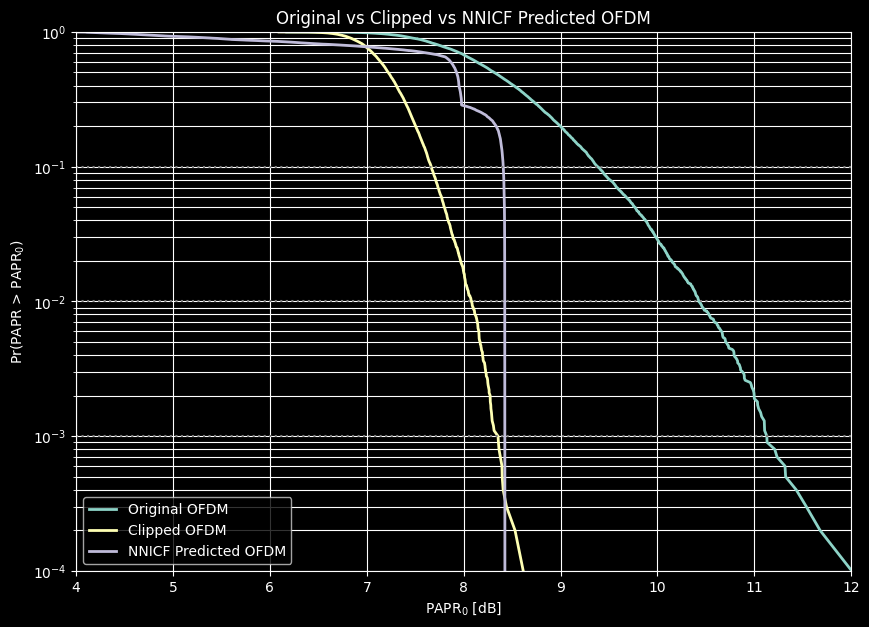

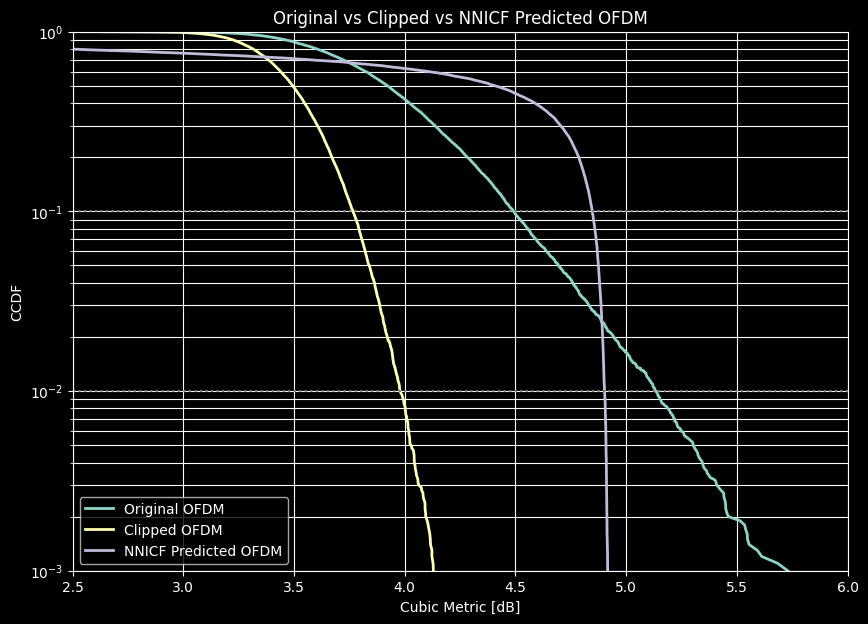

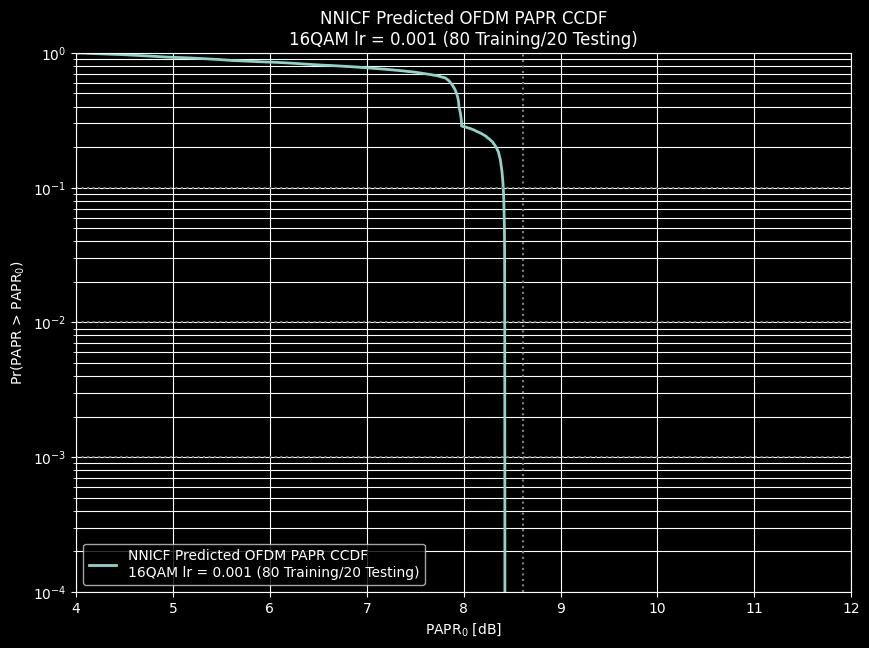

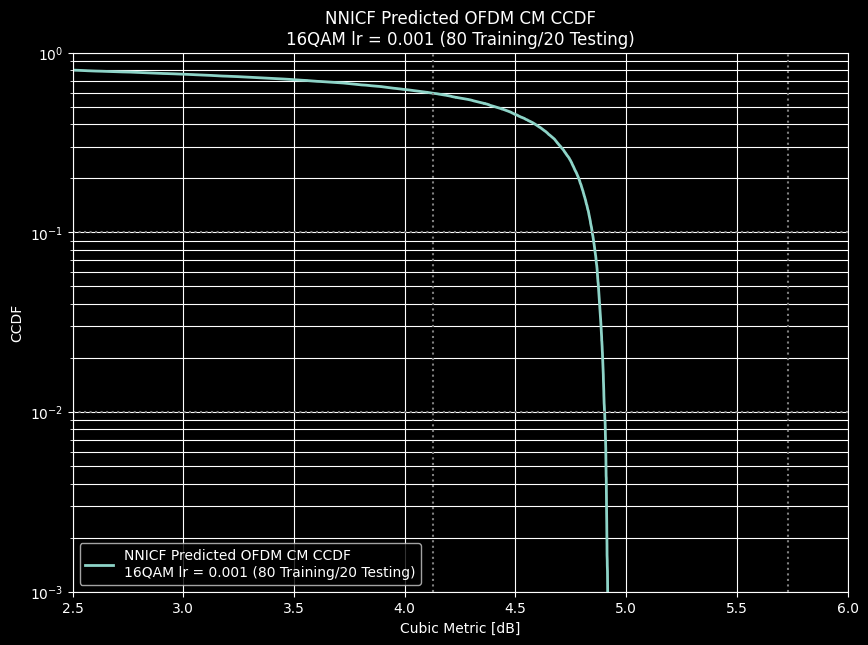

In [19]:
# 5. Calculate PAPR and CM for CCDF
orig_papr, clip_papr, pred_papr = [], [], []
orig_cm, clip_cm, pred_cm = [], [], []

# Iterate through the arrays
for i in range(test_size * 10000 if not one_batch else 10000):
    orig_papr.append(calculate_papr(original_complex[i]))
    clip_papr.append(calculate_papr(clipped_complex[i]))
    pred_papr.append(calculate_papr(predicted_complex[i]))

    orig_cm.append(calculate_cm(original_complex[i]))
    clip_cm.append(calculate_cm(clipped_complex[i]))
    pred_cm.append(calculate_cm(predicted_complex[i]))

orig_papr, clip_papr, pred_papr = np.array(orig_papr), np.array(clip_papr), np.array(pred_papr)
orig_cm, clip_cm, pred_cm = np.array(orig_cm), np.array(clip_cm), np.array(pred_cm)

# 6. Plot the CCDF
title = f"NNICF Predicted OFDM\n{params}"
labels = ['Original OFDM', 'Clipped OFDM', 'NNICF Predicted OFDM']

plot_ccdf_compare([orig_papr, clip_papr, pred_papr], f"Original vs Clipped vs {title}", labels)
plot_ccdf_compare([orig_cm, clip_cm, pred_cm], f"Original vs Clipped vs {title}", labels, metric="CM")


# todo: find an appropriate naming for the 10k
y_axis_len = test_size * 10000 if not one_batch else 10000
y_axis = np.arange(y_axis_len, 0, -1) / y_axis_len # ? why dont we use the theoretical CCDF function
papr_floor = np.where(y_axis == 1e-4)[0]
cm_floor = np.where(y_axis == 1e-3)[0]

papr_vlines = [np.sort(orig_papr)[papr_floor], np.sort(clip_papr)[papr_floor]]
papr_image_path = f'./nngraphs/{mod}_papr_{train_test_str}_{lr_str}.png'
plot_ccdf(pred_papr, title, metric="papr", vlines=papr_vlines, save=papr_image_path)

cm_vlines = [np.sort(orig_cm)[cm_floor], np.sort(clip_cm)[cm_floor]]
cm_image_path = f'./nngraphs/{mod}_cm_{train_test_str}_{lr_str}.png'
plot_ccdf(pred_cm, title, metric="cm", vlines=cm_vlines, save=cm_image_path)